# 11d — Decarbonization toy examples

Three self-contained illustrations of carbon-intensity-constrained
tracking-error portfolio construction (equity in Sections 1-2, a mixed
AS/MD/DTS bond objective in Section 3), comparing a **threshold**
approach (minimize tracking error subject to a CI-reduction target, at a
grid of targets), an **order-statistic** approach (exclude the
highest-CI names one at a time, in descending CI order, then
re-optimize what remains), and a **naive** approach (just renormalize
the benchmark weights over whatever names survive the order-statistic
exclusion, no re-optimization) — plus a static GICS-sector CI-reduction
reference table in Section 4. All four sections are self-contained
(hardcoded data, no external files) and reuse this chapter's core
machinery: `min_te_portfolio` (`11a`) for the equity case, and
`quadratic_form_bond_portfolio2` (`11c`) for the bond case.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def _prune_redundant_rows(A, b, tol=1e-10):
    # See 11a: drops linearly-dependent equality rows so SLSQP's LSQ
    # subproblem doesn't hit a singular Jacobian on a rank-deficient system.
    keep, rows = [], []
    for i in range(A.shape[0]):
        cand = np.vstack(rows + [A[i]]) if rows else A[i:i + 1]
        if np.linalg.matrix_rank(cand, tol=tol) > len(rows):
            rows.append(A[i])
            keep.append(i)
    return A[keep], b[keep]


def min_te_portfolio(b, Sigma, A_eq, b_eq, A_ub=None, b_ub=None, lb=None, ub=None):
    # Minimum-tracking-error portfolio (11a): minimizes (w-b)'Sigma(w-b)
    # subject to linear equality/inequality constraints and box bounds.
    n = len(b)
    lb = np.zeros(n) if lb is None else np.asarray(lb)
    ub = np.ones(n) if ub is None else np.asarray(ub)
    A_eq, b_eq = _prune_redundant_rows(np.asarray(A_eq, dtype=float), np.asarray(b_eq, dtype=float))

    def obj(w):
        d = w - b
        return d @ Sigma @ d

    def obj_grad(w):
        return 2 * Sigma @ (w - b)

    constraints = [{"type": "eq", "fun": lambda w, A=A_eq, c=b_eq: A @ w - c}]
    if A_ub is not None:
        constraints.append({"type": "ineq", "fun": lambda w, A=A_ub, c=b_ub: c - A @ w})

    res = minimize(obj, b.copy(), jac=obj_grad, method="SLSQP",
                    bounds=list(zip(lb, ub)), constraints=constraints,
                    options={"maxiter": 1000, "ftol": 1e-14})
    w = res.x
    w = w * (np.abs(w) >= 1e-10)
    sigma_x = np.sqrt(max((w - b) @ Sigma @ (w - b), 0))
    return w, sigma_x


def quadratic_form(x, Q, R, c):
    # 0.5 x'Qx - x'R + c -- see 11c for the sign-convention derivation.
    x = np.asarray(x, dtype=float)
    return 0.5 * x @ Q @ x - x @ R + c


def _sector_risk_matrices(sector, X, X_star):
    sector = np.asarray(sector)
    X = np.asarray(X, dtype=float)
    sectors = np.unique(sector)
    n = len(X)
    M = np.zeros((len(sectors), n))
    for j, s in enumerate(sectors):
        mask = sector == s
        M[j, mask] = X[mask]
    Q = M.T @ M
    R = M.T @ np.asarray(X_star, dtype=float)
    c = 0.5 * np.sum(np.asarray(X_star, dtype=float) ** 2)
    return Q, R, c


def _shift_by_benchmark(Q, R, c, b):
    b = np.asarray(b, dtype=float)
    return Q, R + Q @ b, 0.5 * b @ Q @ b + b @ R + c


def quadratic_form_bond_portfolio2(sector, varphi_AS, varphi_MD, MD, MD_star, varphi_DTS, DTS,
                                    DTS_star, gamma_carry, carry, b):
    # Benchmark-relative mixed AS/MD/DTS objective (11c) plus a linear
    # carry term, expressed directly in w.
    n = len(b)
    MD_star = np.zeros(len(np.unique(sector))) if MD_star is None else MD_star
    DTS_star = np.zeros(len(np.unique(sector))) if DTS_star is None else DTS_star

    Q_AS, R_AS, c_AS = _sector_risk_matrices(np.arange(n), np.ones(n), np.zeros(n))
    Q_MD, R_MD, c_MD = _sector_risk_matrices(sector, MD, MD_star)
    Q_DTS, R_DTS, c_DTS = _sector_risk_matrices(sector, DTS, DTS_star)

    Q_AS_b, R_AS_b, c_AS_b = _shift_by_benchmark(Q_AS, R_AS, c_AS, b)
    Q_MD_b, R_MD_b, c_MD_b = _shift_by_benchmark(Q_MD, R_MD, c_MD, b)
    Q_DTS_b, R_DTS_b, c_DTS_b = _shift_by_benchmark(Q_DTS, R_DTS, c_DTS, b)

    carry = np.asarray(carry, dtype=float)
    Q_b = varphi_AS * Q_AS_b + varphi_MD * Q_MD_b + varphi_DTS * Q_DTS_b
    R_b = varphi_AS * R_AS_b + varphi_MD * R_MD_b + varphi_DTS * R_DTS_b + gamma_carry * carry
    c_b = (varphi_AS * c_AS_b + varphi_MD * c_MD_b + varphi_DTS * c_DTS_b
           + gamma_carry * (np.asarray(b, dtype=float) @ carry))
    return Q_b, R_b, c_b


def solve_min_quadratic_form(Q, R, c, A_eq, b_eq, A_ub=None, b_ub=None, lb=None, ub=None, x0=None):
    # Minimizes quadratic_form(w,Q,R,c) subject to linear constraints -- a
    # standard quadratic program, since quadratic_form's 0.5x'Qx - x'R is a
    # quadratic objective in w (the additive constant c doesn't affect the
    # argmin).
    n = Q.shape[0]
    lb = np.zeros(n) if lb is None else np.asarray(lb)
    ub = np.ones(n) if ub is None else np.asarray(ub)
    x0 = np.full(n, 1.0 / n) if x0 is None else np.asarray(x0)
    A_eq, b_eq = _prune_redundant_rows(np.asarray(A_eq, dtype=float), np.asarray(b_eq, dtype=float))

    constraints = [{"type": "eq", "fun": lambda w, A=A_eq, c=b_eq: A @ w - c}]
    if A_ub is not None:
        constraints.append({"type": "ineq", "fun": lambda w, A=A_ub, c=b_ub: c - A @ w})

    res = minimize(lambda w: quadratic_form(w, Q, R, c), x0,
                    jac=lambda w: Q @ w - R, method="SLSQP",
                    bounds=list(zip(lb, ub)), constraints=constraints,
                    options={"maxiter": 1000, "ftol": 1e-14})
    return res.x


## 1. Threshold vs. order-statistic vs. naive (equity, R up to 50%)

An 8-asset equity universe with a single-factor (CAPM) covariance
structure $\Sigma=\beta\beta'\sigma_m^2+\mathrm{diag}(\tilde\sigma^2)$.
The **threshold** approach minimizes tracking-error variance subject to
a CI-reduction target (6 grid points, 0-50%). The **order-statistic**
approach excludes assets one at a time in descending CI order (via the
upper bound, `ub=0` for excluded names) and re-optimizes the rest; the
**naive** variant skips the re-optimization and just renormalizes the
benchmark weights over the surviving names.


In [2]:
b = np.array([0.20, 0.19, 0.17, 0.13, 0.12, 0.08, 0.06, 0.05])
CI = np.array([100.5, 97.2, 250.4, 352.3, 27.1, 54.2, 78.6, 426.7])
beta = np.array([0.30, 1.80, 0.85, 0.83, 1.47, 0.94, 1.67, 1.08])
sigma_tilde = np.array([0.10, 0.05, 0.06, 0.12, 0.15, 0.04, 0.08, 0.07])
sigma_m = 0.18
Sigma = np.outer(beta, beta) * sigma_m ** 2 + np.diag(sigma_tilde ** 2)
n = len(b)
CI_b = b @ CI

# -- threshold --
R_grid = np.array([0.00, 0.10, 0.20, 0.30, 0.40, 0.50])
w1 = np.zeros((n, len(R_grid)))
sigma_w1 = np.zeros(len(R_grid))
for i, R in enumerate(R_grid):
    w1[:, i], sigma_w1[i] = min_te_portfolio(b, Sigma, np.ones((1, n)), np.array([1.0]),
                                              CI.reshape(1, -1), np.array([(1 - R) * CI_b]))
CI_w1 = w1.T @ CI
R_w1 = 1 - CI_w1 / CI_b
table1 = pd.DataFrame(100 * w1, index=[f"Asset {i+1}" for i in range(n)],
                       columns=[f"R={int(100*r)}%" for r in R_grid]).T
table1["sigma(w|b), bps"] = 1e4 * sigma_w1
table1["Reduction %"] = 100 * R_w1
display(table1.round(2))

# -- order-statistic and naive --
CI_order = np.sort(CI)[::-1]
w2 = np.zeros((n, n))
sigma_w2 = np.zeros(n)
w3 = np.zeros((n, n))
sigma_w3 = np.zeros(n)
for i in range(n):
    ub = (CI <= CI_order[i]).astype(float)
    w2[:, i], sigma_w2[i] = min_te_portfolio(b, Sigma, np.ones((1, n)), np.array([1.0]), ub=ub)
    w3[:, i] = (b * ub) / (b * ub).sum()
    sigma_w3[i] = np.sqrt((w3[:, i] - b) @ Sigma @ (w3[:, i] - b))

CI_w2, CI_w3 = w2.T @ CI, w3.T @ CI
R_w2, R_w3 = 1 - CI_w2 / CI_b, 1 - CI_w3 / CI_b
table2 = pd.DataFrame({"order-statistic sigma, bps": 1e4 * sigma_w2, "order-statistic Reduction %": 100 * R_w2,
                        "naive sigma, bps": 1e4 * sigma_w3, "naive Reduction %": 100 * R_w3},
                       index=[f"m={i}" for i in range(n)])
display(table2.round(2))

,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,"sigma(w|b), bps",Reduction %
R=0%,20.00,19.00,17.00,13.00,12.00,8.00,6.00,5.00,0.00,0.0
R=10%,20.54,19.33,15.67,12.28,12.26,11.71,6.36,1.86,30.01,10.0
R=20%,21.14,19.29,12.91,10.95,12.60,16.42,6.69,0.00,61.90,20.0
R=30%,21.86,18.70,8.06,8.74,13.07,22.57,7.00,0.00,104.10,30.0
R=40%,22.58,18.11,3.22,6.53,13.53,28.73,7.30,0.00,149.65,40.0
R=50%,22.96,17.23,0.00,3.36,14.08,34.77,7.59,0.00,196.87,50.0


,"order-statistic sigma, bps",order-statistic Reduction %,"naive sigma, bps",naive Reduction %
m=0,0.00,0.00,0.00,0.00
m=1,37.15,9.62,39.49,8.72
m=2,168.21,29.33,184.88,29.04
m=3,224.78,54.05,304.32,51.26
m=4,397.88,65.70,945.64,57.41
m=5,403.85,67.04,807.67,70.53
m=6,429.88,69.42,865.36,76.37
m=7,1541.05,83.12,1541.05,83.12


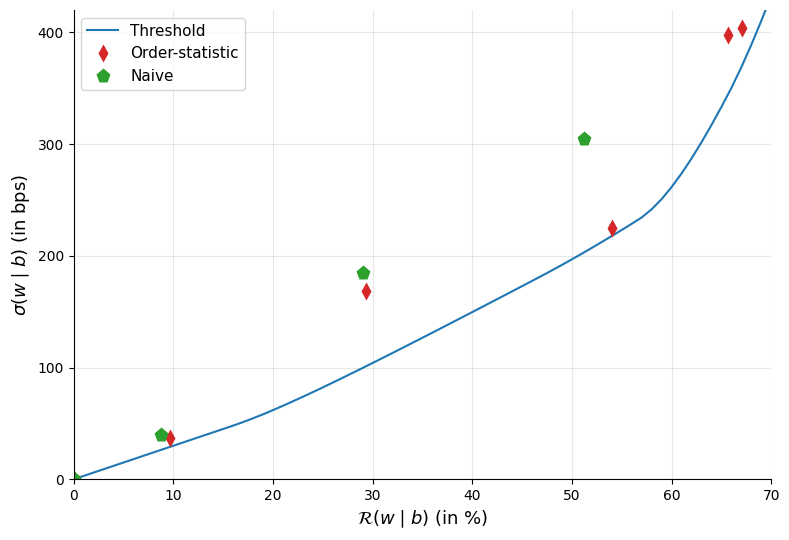

In [3]:
# -- efficient frontier --
R_fine = np.arange(0, 0.701, 0.01)
w_ef = np.zeros((n, len(R_fine)))
sigma_ef = np.zeros(len(R_fine))
for i, R in enumerate(R_fine):
    w_ef[:, i], sigma_ef[i] = min_te_portfolio(b, Sigma, np.ones((1, n)), np.array([1.0]),
                                                CI.reshape(1, -1), np.array([(1 - R) * CI_b]))
CI_ef = w_ef.T @ CI
R_ef = 1 - CI_ef / CI_b

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(100 * R_ef, 1e4 * sigma_ef, "-", color="tab:blue", linewidth=1.5, label="Threshold")
ax.plot(100 * R_w2, 1e4 * sigma_w2, "d", markerfacecolor="tab:red", markeredgecolor="none",
        markersize=9, linestyle="None", label="Order-statistic")
ax.plot(100 * R_w3, 1e4 * sigma_w3, "p", markerfacecolor="tab:green", markeredgecolor="none",
        markersize=11, linestyle="None", label="Naive")
ax.set_xlabel(r"$\mathcal{R}(w \mid b)$ (in %)", fontsize=13)
ax.set_ylabel(r"$\sigma(w \mid b)$ (in bps)", fontsize=13)
ax.set_xlim(0, 70)
ax.set_xticks(range(0, 71, 10))
ax.set_ylim(0, 420)
ax.set_yticks(range(0, 421, 100))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()

## 2. Same idea, wider range (R up to 90%) with an interpolated naive curve

Same universe, same three approaches, but the threshold grid now runs to
90% and the naive approach is **linearly interpolated** between its 8
discrete order-statistic points so it can be compared to the threshold
curve at every reduction level, not just the 8 achievable ones. **Note**:
this figure's y-axis is scaled by `1e2` (not `1e4` as in Section 1) while
keeping the same "(in bps)" axis label, reproduced literally here since
the resulting y-limits (`[0,16]`) only make sense with the `1e2`
scaling — the values plotted are closer to "hundredths of a percent"
than basis points at that scale, an axis-labeling quirk rather than a
meaningful unit change.


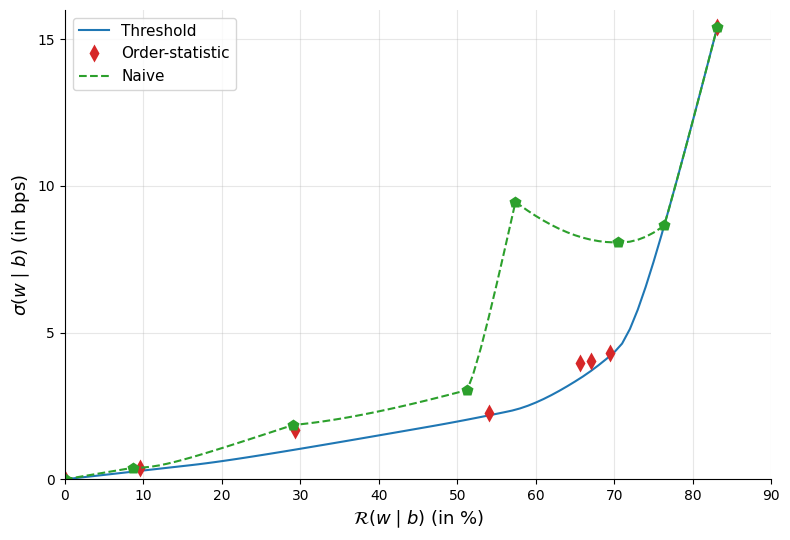

In [4]:
R_grid2 = np.arange(0, 0.901, 0.01)
w1b = np.zeros((n, len(R_grid2)))
sigma_w1b = np.zeros(len(R_grid2))
for i, R in enumerate(R_grid2):
    w1b[:, i], sigma_w1b[i] = min_te_portfolio(b, Sigma, np.ones((1, n)), np.array([1.0]),
                                                CI.reshape(1, -1), np.array([(1 - R) * CI_b]))
CI_w1b = w1b.T @ CI
R_w1b = 1 - CI_w1b / CI_b

# order-statistic / naive (same construction as Section 1, same 8 points)
R_w3_sorted = R_w3  # from Section 1

R_grid_interp = np.arange(0, 0.901, 0.01)
w4 = np.zeros((n, len(R_grid_interp)))
sigma_w4 = np.zeros(len(R_grid_interp))
R_w4 = np.zeros(len(R_grid_interp))
for i, R in enumerate(R_grid_interp):
    cnd = np.where(R_w3_sorted > R)[0]
    if len(cnd) == 0:
        w_1 = w3[:, -1]
        w_2 = w3[:, -1]
        alpha = 0.5
    else:
        idx = cnd[0]
        w_1 = w3[:, idx - 1]
        w_2 = w3[:, idx]
        alpha = (R_w3_sorted[idx] - R) / (R_w3_sorted[idx] - R_w3_sorted[idx - 1])
    w = alpha * w_1 + (1 - alpha) * w_2
    w4[:, i] = w
    sigma_w4[i] = np.sqrt((w - b) @ Sigma @ (w - b))
    R_w4[i] = 1 - (w @ CI) / CI_b

R_w4_full = np.concatenate([R_w3_sorted, R_w4])
sigma_w4_full = np.concatenate([sigma_w3, sigma_w4])
is_breakpoint = np.concatenate([np.ones(len(R_w3_sorted), dtype=bool), np.zeros(len(R_w4), dtype=bool)])
order = np.argsort(R_w4_full)
R_w4_full, sigma_w4_full, is_breakpoint = R_w4_full[order], sigma_w4_full[order], is_breakpoint[order]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(100 * R_w1b, 1e2 * sigma_w1b, "-", color="tab:blue", linewidth=1.5, label="Threshold")
ax.plot(100 * R_w2, 1e2 * sigma_w2, "d", markerfacecolor="tab:red", markeredgecolor="none",
        markersize=9, linestyle="None", label="Order-statistic")
ax.plot(100 * R_w4_full, 1e2 * sigma_w4_full, "--", color="tab:green", linewidth=1.5, label="Naive")
ax.plot(100 * R_w4_full[is_breakpoint], 1e2 * sigma_w4_full[is_breakpoint], "p",
        markerfacecolor="tab:green", markeredgecolor="none", markersize=9, linestyle="None")
ax.set_xlabel(r"$\mathcal{R}(w \mid b)$ (in %)", fontsize=13)
ax.set_ylabel(r"$\sigma(w \mid b)$ (in bps)", fontsize=13)
ax.set_xlim(0, 90)
ax.set_xticks(range(0, 91, 10))
ax.set_ylim(0, 16)
ax.set_yticks(range(0, 16, 5))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Bond mixed AS/MD/DTS objective: threshold vs. order-statistic

An 8-asset/2-sector bond universe, using the mixed active-share/MD/DTS
objective (`quadratic_form_bond_portfolio2` from `11c`, with default
zero-deviation targets and no carry) in place of the equity
tracking-error variance, solved via `solve_min_quadratic_form` as a
quadratic program.


In [5]:
CI3 = np.array([100.5, 97.2, 250.4, 352.3, 27.1, 54.2, 78.6, 426.7])
MD3 = np.array([3.10, 8.60, 7.20, 5.00, 4.70, 2.10, 8.10, 2.60])
DTS3 = np.array([100, 155, 575, 436, 159, 145, 804, 365])
Sector3 = np.array([1, 2, 1, 1, 2, 2, 2, 1])
varphi_AS3, varphi_MD3, varphi_DTS3 = 100, 25, 0.001
CI3_b = b @ CI3

Q_b3, R_b3, c_b3 = quadratic_form_bond_portfolio2(Sector3, varphi_AS3, varphi_MD3, MD3, None,
                                                    varphi_DTS3, DTS3, None, 0, np.zeros(n), b)

def bond_metrics(w):
    d = w - b
    sectors = np.unique(Sector3)
    AS = 0.5 * np.abs(d).sum()
    sigma_MD = np.sqrt(sum(((d * MD3)[Sector3 == s].sum()) ** 2 for s in sectors))
    sigma_DTS = np.sqrt(sum(((d * DTS3)[Sector3 == s].sum()) ** 2 for s in sectors))
    return AS, w @ MD3, w @ DTS3, sigma_MD, sigma_DTS, w @ CI3, 1 - (w @ CI3) / CI3_b

R_grid3 = np.array([0.00, 0.10, 0.20, 0.30, 0.40, 0.50])
rows1 = []
for R in R_grid3:
    w = solve_min_quadratic_form(Q_b3, R_b3, c_b3, np.ones((1, n)), np.array([1.0]),
                                  CI3.reshape(1, -1), np.array([(1 - R) * CI3_b]), x0=b)
    AS_w, MD_w, DTS_w, sMD, sDTS, CI_w, Rw = bond_metrics(w)
    rows1.append({"R target": R, **{f"Asset {i+1}": 100 * w[i] for i in range(n)},
                   "AS(w|b) %": 100 * AS_w, "MD(w)": MD_w, "DTS(w)": DTS_w,
                   "sigma_MD": sMD, "sigma_DTS": sDTS, "CI(w)": CI_w, "Reduction %": 100 * Rw})
print("Threshold approach")
display(pd.DataFrame(rows1).round(2))

CI3_order = np.sort(CI3)[::-1]
rows2 = []
for i in range(n):
    ub = (CI3 <= CI3_order[i]).astype(float)
    w = solve_min_quadratic_form(Q_b3, R_b3, c_b3, np.ones((1, n)), np.array([1.0]), lb=np.zeros(n), ub=ub, x0=b)
    AS_w, MD_w, DTS_w, sMD, sDTS, CI_w, Rw = bond_metrics(w)
    rows2.append({"m": i, **{f"Asset {j+1}": 100 * w[j] for j in range(n)},
                  "AS(w|b) %": 100 * AS_w, "MD(w)": MD_w, "DTS(w)": DTS_w,
                  "sigma_MD": sMD, "sigma_DTS": sDTS, "CI(w)": CI_w, "Reduction %": 100 * Rw})
print("Order-statistic approach")
display(pd.DataFrame(rows2).round(2))

Threshold approach


,R target,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,AS(w|b) %,MD(w),DTS(w),sigma_MD,sigma_DTS,CI(w),Reduction %
0,0.0,20.00,19.00,17.00,13.00,12.00,8.00,6.00,5.00,0.00,5.48,301.05,0.00,0.00,160.57,0.0
1,0.1,21.62,18.18,18.92,11.34,13.72,9.60,5.56,1.05,6.87,5.49,292.34,0.01,8.99,144.52,10.0
2,0.2,23.93,16.98,21.94,5.35,16.14,10.47,5.19,0.00,15.49,5.45,282.28,0.04,19.29,128.46,20.0
3,0.3,26.72,14.18,22.65,0.00,21.63,10.06,4.75,0.00,24.07,5.29,266.12,0.17,35.74,112.40,30.0
4,0.4,30.08,7.88,16.82,0.00,33.89,7.21,4.11,0.00,31.97,4.90,236.45,0.49,65.88,96.34,40.0
5,0.5,33.44,1.58,11.00,0.00,46.14,4.36,3.48,0.00,47.58,4.51,206.78,0.81,96.01,80.29,50.0


Order-statistic approach


,m,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,AS(w|b) %,MD(w),DTS(w),sigma_MD,sigma_DTS,CI(w),Reduction %
0,0,20.00,19.00,17.00,13.00,12.00,8.00,6.00,5.0,0.00,5.48,301.05,0.00,0.00,160.57,0.00
1,1,20.83,18.60,17.79,14.53,12.89,9.74,5.62,0.0,5.78,5.52,295.08,0.03,6.21,147.94,7.87
2,2,24.62,18.13,26.30,0.00,13.96,11.85,5.15,0.0,19.72,5.54,284.71,0.04,16.87,122.46,23.74
3,3,64.64,21.32,0.00,0.00,6.00,0.00,8.03,0.0,49.00,4.77,171.82,0.63,128.04,93.63,41.69
4,4,0.00,3.32,0.00,0.00,36.57,60.11,0.00,0.0,76.68,3.27,150.45,2.66,197.22,45.72,71.53
5,5,0.00,0.00,0.00,0.00,41.27,58.73,0.00,0.0,80.00,3.17,150.78,2.64,197.29,43.02,73.21
6,6,0.00,0.00,0.00,0.00,41.27,58.73,0.00,0.0,80.00,3.17,150.78,2.64,197.29,43.02,73.21
7,7,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.0,88.00,4.70,159.00,3.21,199.22,27.10,83.12


## 4. GICS-sector CI-reduction reference table

A static table: 4 illustrative CI values per GICS sector (a
low/median/high/max-style spread across constituents) and the
corresponding target intensity $CI^\star=(1-R)\cdot CI$ under each
sector's fixed reduction rate $R$.


In [6]:
sectors4 = ["Communication Services", "Consumer Discretionary", "Consumer Staples", "Energy",
            "Financials", "Health Care", "Industrials", "Information Technology", "Materials",
            "Real Estate", "Utilities", "MSCI World"]
R4 = np.array([0.524, 0.524, 0.524, 0.569, 0.524, 0.524, 0.188, 0.524, 0.367, 0.367, 0.569, 0.366])
CI4 = np.array([
    [2, 28, 134, 172],
    [23, 65, 206, 590],
    [28, 55, 401, 929],
    [632, 698, 1006, 6823],
    [13, 19, 52, 244],
    [10, 22, 120, 146],
    [111, 130, 298, 1662],
    [7, 23, 112, 239],
    [478, 702, 1113, 2957],
    [22, 101, 167, 571],
    [1744, 1794, 2053, 2840],
    [130, 163, 310, 992],
])
CI_star4 = (1 - R4)[:, None] * CI4

table4 = pd.DataFrame(CI4, index=sectors4, columns=["CI (col 1)", "CI (col 2)", "CI (col 3)", "CI (col 4)"])
table4["R (%)"] = 100 * R4
for j in range(4):
    table4[f"CI* (col {j+1})"] = CI_star4[:, j]
display(table4.round(1))

,CI (col 1),CI (col 2),CI (col 3),CI (col 4),R (%),CI* (col 1),CI* (col 2),CI* (col 3),CI* (col 4)
Communication Services,2,28,134,172,52.4,1.0,13.3,63.8,81.9
Consumer Discretionary,23,65,206,590,52.4,10.9,30.9,98.1,280.8
Consumer Staples,28,55,401,929,52.4,13.3,26.2,190.9,442.2
Energy,632,698,1006,6823,56.9,272.4,300.8,433.6,2940.7
Financials,13,19,52,244,52.4,6.2,9.0,24.8,116.1
Health Care,10,22,120,146,52.4,4.8,10.5,57.1,69.5
Industrials,111,130,298,1662,18.8,90.1,105.6,242.0,1349.5
Information Technology,7,23,112,239,52.4,3.3,10.9,53.3,113.8
Materials,478,702,1113,2957,36.7,302.6,444.4,704.5,1871.8
Real Estate,22,101,167,571,36.7,13.9,63.9,105.7,361.4
